In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df=pd.read_csv(r"C:\Users\vighp\OneDrive\Desktop\credit data.csv")

df

,Creditability,Account_Balance,Duration_of_Credit_monthly,Payment_Status_of_Previous_Credit,Purpose,Credit_Amount,Value_Savings_Stocks,Length_of_current_employment,Instalment_per_cent,Sex_Marital_Status,...,Duration_in_Current_address,Most_valuable_available_asset,Age_years,Concurrent_Credits,Type_of_apartment,No_of_Credits_at_this_Bank,Occupation,No_of_dependents,Telephone,Foreign_Worker
0,1,1,18,4,2,1049,1,2,4,2,...,4,2,21,3,1,1,3,1,1,1
1,1,1,9,4,0,2799,1,3,2,3,...,2,1,36,3,1,2,3,2,1,1
2,1,2,12,2,9,841,2,4,2,2,...,4,1,23,3,1,1,2,1,1,1
3,1,1,12,4,0,2122,1,3,3,3,...,2,1,39,3,1,2,2,2,1,2
4,1,1,12,4,0,2171,1,3,4,3,...,4,2,38,1,2,2,2,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,1,24,2,3,1987,1,3,2,3,...,4,1,21,3,1,1,2,2,1,1
996,0,1,24,2,0,2303,1,5,4,3,...,1,1,45,3,2,1,3,1,1,1
997,0,4,21,4,0,12680,5,5,4,3,...,4,4,30,3,3,1,4,1,2,1
998,0,2,12,2,3,6468,5,1,2,3,...,1,4,52,3,2,1,4,1,2,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   Creditability                      1000 non-null   int64
 1   Account_Balance                    1000 non-null   int64
 2   Duration_of_Credit_monthly         1000 non-null   int64
 3   Payment_Status_of_Previous_Credit  1000 non-null   int64
 4   Purpose                            1000 non-null   int64
 5   Credit_Amount                      1000 non-null   int64
 6   Value_Savings_Stocks               1000 non-null   int64
 7   Length_of_current_employment       1000 non-null   int64
 8   Instalment_per_cent                1000 non-null   int64
 9   Sex_Marital_Status                 1000 non-null   int64
 10  Guarantors                         1000 non-null   int64
 11  Duration_in_Current_address        1000 non-null   int64
 12  Most_valuable_availab

In [9]:
df.isna().sum()

Creditability                        0
Account_Balance                      0
Duration_of_Credit_monthly           0
Payment_Status_of_Previous_Credit    0
Purpose                              0
Credit_Amount                        0
Value_Savings_Stocks                 0
Length_of_current_employment         0
Instalment_per_cent                  0
Sex_Marital_Status                   0
Guarantors                           0
Duration_in_Current_address          0
Most_valuable_available_asset        0
Age_years                            0
Concurrent_Credits                   0
Type_of_apartment                    0
No_of_Credits_at_this_Bank           0
Occupation                           0
No_of_dependents                     0
Telephone                            0
Foreign_Worker                       0
dtype: int64

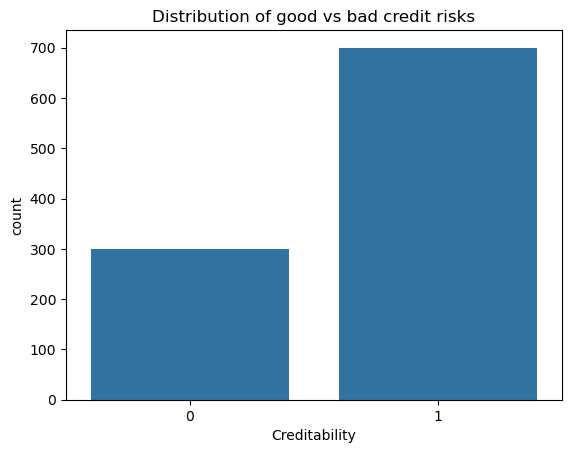

In [10]:
sns.countplot(data=df,x='Creditability')
plt.title("Distribution of good vs bad credit risks")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X = df[['Age_years', 'Credit_Amount', 'Duration_of_Credit_monthly']] 
y = df['Creditability'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

log_model = LogisticRegression().fit(X_train, y_train)
tree_model = DecisionTreeClassifier(max_depth=3).fit(X_train, y_train)

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

log_predictions=log_model.predict(X_test)
tree_predictions=tree_model.predict(X_test)

print("Logistic Regression")
print("Accuracy:",accuracy_score(y_test,log_predictions))
print("Confusion Matrix:",confusion_matrix(y_test,log_predictions))

print("Decision Tree")
print("Accuracy:",accuracy_score(y_test,tree_predictions))
print("Confusion_matrix:",confusion_matrix(y_test,tree_predictions))

Logistic Regression
Accuracy: 0.6833333333333333
Confusion Matrix: [[ 13  81]
 [ 14 192]]
Decision Tree
Accuracy: 0.65
Confusion_matrix: [[ 21  73]
 [ 32 174]]


In [13]:
df.groupby('Creditability')[['Duration_of_Credit_monthly', 'Credit_Amount']].mean()

,Duration_of_Credit_monthly,Credit_Amount
Creditability,,
0,24.860000,3938.126667
1,19.207143,2985.442857


[Text(0.5, 0.875, 'x[1] <= 6721.0\ngini = 0.415\nsamples = 700\nvalue = [206.0, 494.0]'),
 Text(0.25, 0.625, 'x[2] <= 15.5\ngini = 0.386\nsamples = 621\nvalue = [162.0, 459.0]'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[1] <= 954.5\ngini = 0.305\nsamples = 304\nvalue = [57, 247]'),
 Text(0.0625, 0.125, 'gini = 0.43\nsamples = 67\nvalue = [21, 46]'),
 Text(0.1875, 0.125, 'gini = 0.258\nsamples = 237\nvalue = [36, 201]'),
 Text(0.375, 0.375, 'x[0] <= 23.5\ngini = 0.443\nsamples = 317\nvalue = [105.0, 212.0]'),
 Text(0.3125, 0.125, 'gini = 0.472\nsamples = 21\nvalue = [13, 8]'),
 Text(0.4375, 0.125, 'gini = 0.428\nsamples = 296\nvalue = [92, 204]'),
 Text(0.75, 0.625, 'x[0] <= 29.5\ngini = 0.494\nsamples = 79\nvalue = [44, 35]'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[0] <= 22.0\ngini = 0.33\nsamples = 24\nvalue = [19, 5]'),
 Text(0.5625, 0.125, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.6875, 0.125, 'gini = 0.236\nsamples = 22\nvalue = [19, 3]'),
 Text

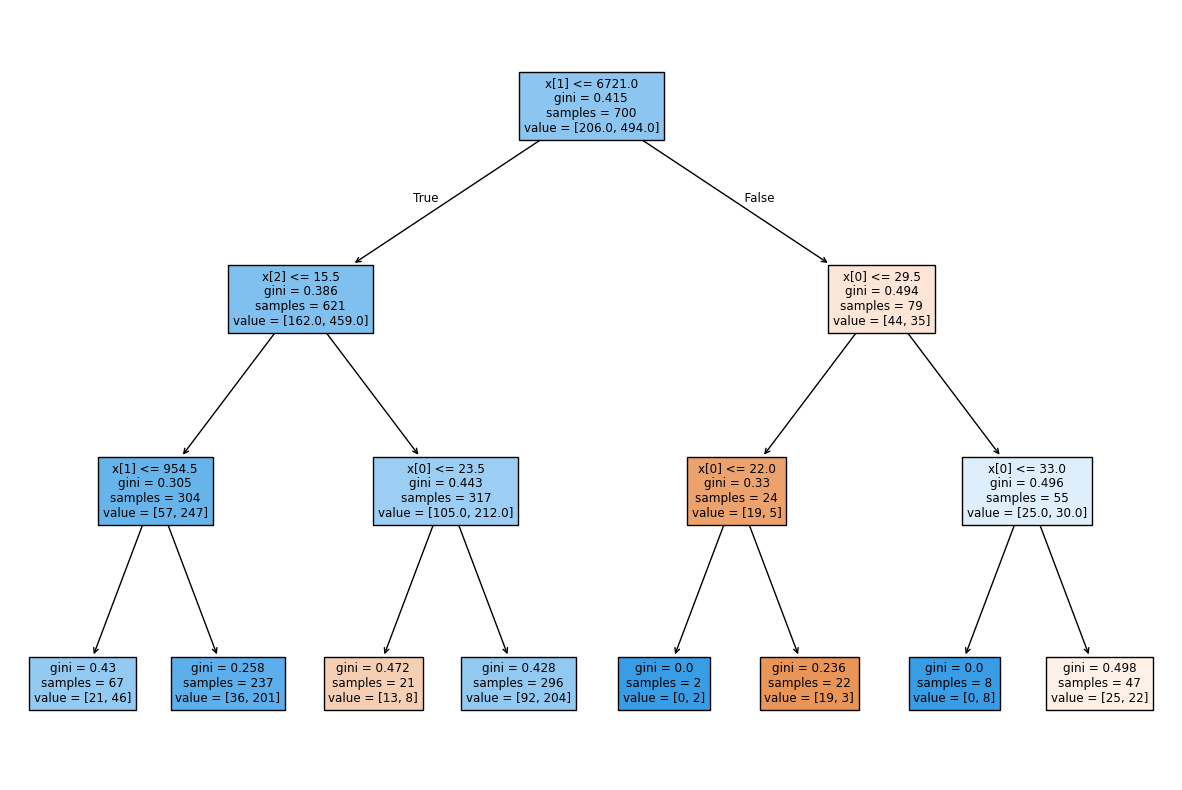

In [16]:
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(tree_model,filled=True)